# 01 — Análisis exploratorio de datos

**Laboratorio 1: Series de Tiempo — CC3084**
**Dataset:** `Base_Migracion_2009-2026jun.xlsx`, enero 2009 – junio 2026 (210 meses, 161,036 registros)

In [1]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import config
from utils_ts import cargar_serie, graficar_serie

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DIR_IMG = config.RAIZ / "informe" / "img"
DIR_IMG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(config.RUTA_LIMPIO, parse_dates=[config.COL_FECHA])
visitantes = df[df["Tipo de Viajero"].isin(config.TIPOS_VISITANTE)].copy()

print(f"dataset limpio: {len(df):,} filas, {df.shape[1]} columnas")
print(f"visitantes (Turista + Excursionista): {len(visitantes):,} filas, "
      f"{visitantes['Viajero'].sum():,.0f} viajeros")

dataset limpio: 161,036 filas, 14 columnas
visitantes (Turista + Excursionista): 137,642 filas, 46,711,913 viajeros


## 1.a Serie temporal del total mensual

Total de viajeros internacionales por mes, enero 2009
– junio 2026.

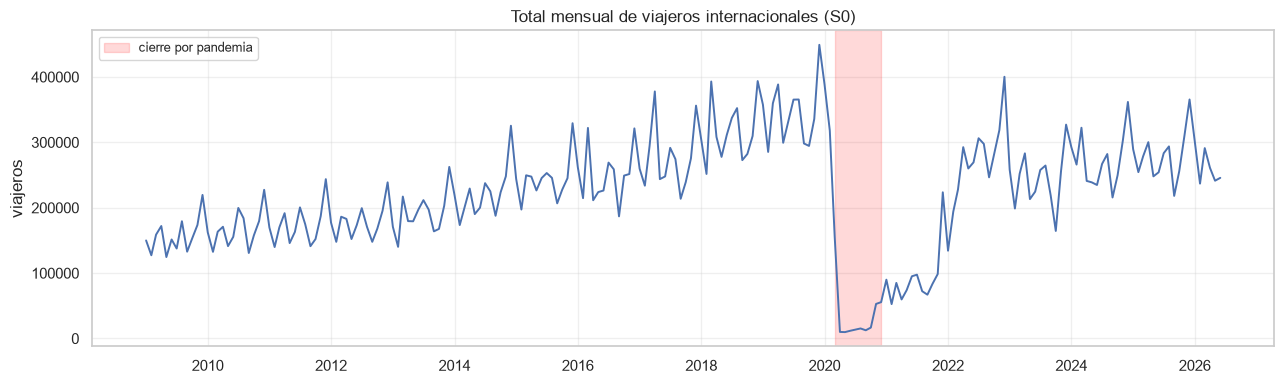

count       210.000000
mean     222437.680412
std       84724.938827
min        9779.000000
25%      170714.476564
50%      227605.662595
75%      278341.208767
max      449114.070500
Name: S0_total, dtype: float64


In [2]:
s0 = cargar_serie("S0_total")

ax = graficar_serie(s0, titulo="Total mensual de viajeros internacionales (S0)")
ax.figure.savefig(DIR_IMG / "1a_serie_total.png", bbox_inches="tight")
plt.show()

print(s0.describe())

Se puede ver que entre 2009 y 2019 la serie mantiene una tendencia de crecimiento y también presenta un patrón estacional, ya que los valores altos y bajos se repiten aproximadamente cada 12 meses, coincidiendo con las temporadas alta y baja del turismo. En marzo de 2020 ocurre una caída muy fuerte debido al cierre de fronteras por la pandemia y el valor más bajo se registra en mayo de 2020, con 9,779 viajeros, lo que equivale a solo el 2.8% del promedio histórico de 222,438 viajeros.

Después de ese punto, la serie empieza a recuperarse poco a poco durante 2021 y 2022. A partir de 2023 los datos se mantienen en un nivel diferente al que se observaba antes de la pandemia. Esto se debe a un cambio metodológico en el que dejaron de incluir a los compradores fronterizos frecuentes dentro de la categoría de Viajero. Sin embargo, como esta serie solo considera Turista y Excursionista, ese cambio tiene un efecto mucho menor que en la serie sin filtrar.

## 1.b Top 10 países de residencia

Se excluye `Cruceristas`, que aparece contaminando la columna `País` (es un tipo
de viajero, no un país — ver `codebook.md`).

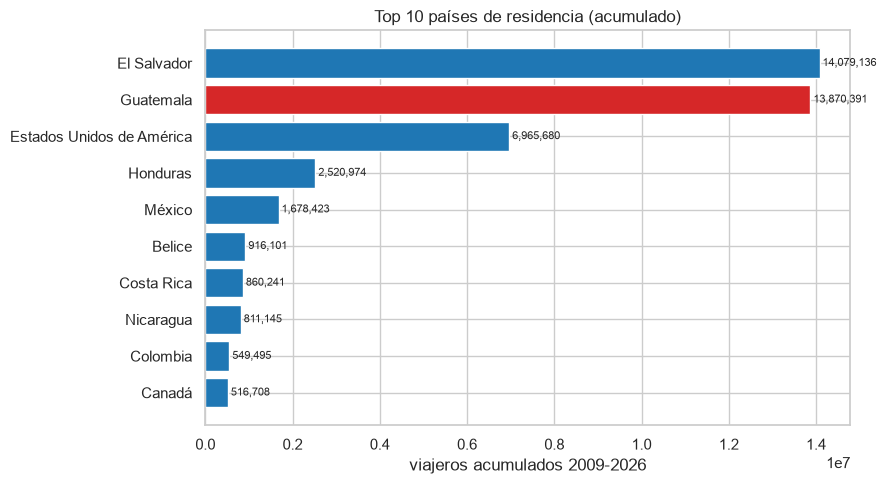

País
El Salvador                  1.407914e+07
Guatemala                    1.387039e+07
Estados Unidos de América    6.965680e+06
Honduras                     2.520974e+06
México                       1.678423e+06
Belice                       9.161011e+05
Costa Rica                   8.602407e+05
Nicaragua                    8.111454e+05
Colombia                     5.494947e+05
Canadá                       5.167079e+05
Name: Viajero, dtype: float64

In [3]:
top_pais = (visitantes[visitantes["País"] != config.VALOR_CONTAMINANTE]
            .groupby("País")["Viajero"].sum()
            .sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(9, 5))
colores = ["#d62728" if p == config.PAIS_EXCLUIDO else "#1f77b4" for p in top_pais.index]
ax.barh(top_pais.index[::-1], top_pais.values[::-1], color=colores[::-1])
ax.set_xlabel("viajeros acumulados 2009-2026")
ax.set_title("Top 10 países de residencia (acumulado)")
for i, v in enumerate(top_pais.values[::-1]):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=8)
plt.tight_layout()
fig.savefig(DIR_IMG / "1b_top_paises.png", bbox_inches="tight")
plt.show()

top_pais

El Top 3 por número acumulado de viajeros está formado por El Salvador con 14.1 millones, Guatemala con 13.9 millones y Estados Unidos con 7.0 millones. Sin embargo, en el caso de Guatemala esos registros corresponden a residentes guatemaltecos que regresan al país y no a turistas extranjeros. Por esa razón, para el análisis de las series de tiempo no se considera Guatemala y el Top 3 queda conformado por El Salvador, Estados Unidos y Honduras.

También se puede ver que existe una fuerte concentración regional, ya que los cuatro países con mayor cantidad de viajeros son El Salvador, Guatemala, Estados Unidos y Honduras. Esto indica que la mayor parte de los visitantes proviene de Centroamérica y Norteamérica, por lo que el mercado emisor no está muy diversificado.


## 1.c Top regiones

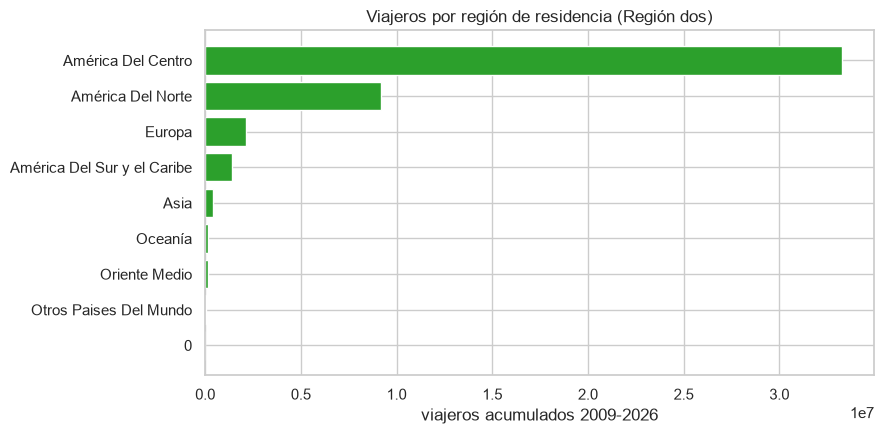

Región dos
América Del Centro             3.328393e+07
América Del Norte              9.160810e+06
Europa                         2.149271e+06
América Del Sur y el Caribe    1.413590e+06
Asia                           4.103335e+05
Oceanía                        1.355054e+05
Oriente Medio                  1.337352e+05
Otros Paises Del Mundo         2.391430e+04
0                              8.210000e+02
Name: Viajero, dtype: float64

In [4]:
top_region = (visitantes[visitantes["Región dos"] != config.VALOR_CONTAMINANTE]
              .groupby("Región dos")["Viajero"].sum()
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(top_region.index[::-1], top_region.values[::-1], color="#2ca02c")
ax.set_xlabel("viajeros acumulados 2009-2026")
ax.set_title("Viajeros por región de residencia (Región dos)")
plt.tight_layout()
fig.savefig(DIR_IMG / "1c_top_regiones.png", bbox_inches="tight")
plt.show()

top_region

Se puede ver que Centroamérica concentra la mayor cantidad de viajeros, con 33.3 millones, lo que representa alrededor del 71% del total. En segundo lugar se encuentra América del Norte con 9.2 millones de viajeros, equivalente a cerca del 20%. En cambio, el resto de las regiones, como Europa, Sudamérica y el Caribe, Asia, Oceanía y Medio Oriente, en conjunto representan menos del 9% del total.

Estos resultados muestran que la mayor parte del turismo receptivo de Guatemala proviene de países cercanos, especialmente de la región centroamericana. Además, esto es consistente con el hecho de que los principales puntos de ingreso son las fronteras terrestres, las cuales registran un mayor volumen de viajeros que muchas de las rutas aéreas internacionales.


## 1.d Distribución por vía y por frontera

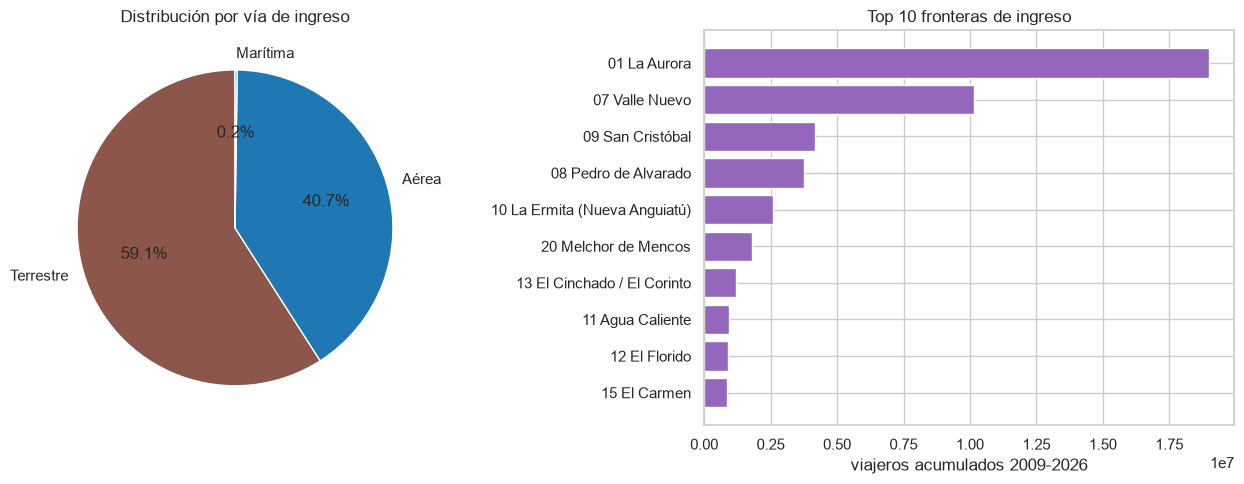

Vía
Terrestre    2.759225e+07
Aérea        1.901942e+07
Marítima     1.002410e+05
Name: Viajero, dtype: float64

Frontera
01 La Aurora                     1.898998e+07
07 Valle Nuevo                   1.014305e+07
09 San Cristóbal                 4.183632e+06
08 Pedro de Alvarado             3.764229e+06
10 La Ermita (Nueva Anguiatú)    2.587072e+06
20 Melchor de Mencos             1.782864e+06
13 El Cinchado / El Corinto      1.213485e+06
11 Agua Caliente                 9.224195e+05
12 El Florido                    9.103735e+05
15 El Carmen                     8.526631e+05
Name: Viajero, dtype: float64


In [5]:
via = visitantes.groupby("Vía")["Viajero"].sum().sort_values(ascending=False)
top_frontera = visitantes.groupby("Frontera")["Viajero"].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(via.values, labels=via.index, autopct="%1.1f%%", startangle=90,
            colors=["#8c564b", "#1f77b4", "#17becf"])
axes[0].set_title("Distribución por vía de ingreso")

axes[1].barh(top_frontera.index[::-1], top_frontera.values[::-1], color="#9467bd")
axes[1].set_xlabel("viajeros acumulados 2009-2026")
axes[1].set_title("Top 10 fronteras de ingreso")

plt.tight_layout()
fig.savefig(DIR_IMG / "1d_via_frontera.png", bbox_inches="tight")
plt.show()

print(via)
print()
print(top_frontera)

Se puede ver que la vía terrestre concentra la mayor parte de los visitantes, con el 59.2% del total, seguida por la vía aérea con el 40.8%. En cambio, la vía marítima representa apenas el 0.2%, por lo que su participación es muy baja y no se consideró para el análisis.

A nivel de fronteras, La Aurora es el principal punto de ingreso al país con 19.0 millones de viajeros. Después se encuentran Valle Nuevo con 10.1 millones y San Cristóbal con 4.2 millones. Estas tres fronteras fueron seleccionadas para el análisis porque representan dos tipos de ingreso diferentes: el transporte aéreo y el terrestre, lo que permite comparar el comportamiento de ambos perfiles de viajeros.


## 1.e Nulos, duplicados y atípicos

In [6]:
print("--- valores nulos ---")
print(df.isna().sum().to_string())
print(f"\ntotal de nulos: {df.isna().sum().sum()}")

--- valores nulos ---
fecha                    0
Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0

total de nulos: 0


No hay valores faltantes en ninguna columna del dataset limpio (confirmado
también en `02_limpieza.py` al construirlo).

In [7]:
CLAVE = ["fecha", "Vía", "Frontera", "País", "Tipo de Viajero"]
dup_clave = df.duplicated(subset=CLAVE).sum()
dup_clave_ext = df.duplicated(subset=CLAVE + ["Agrupación Residencia"]).sum()

print(f"filas que repiten la clave declarada por la fuente (mes+vía+frontera+país+tipo): {dup_clave}")
print(f"filas que repiten esa clave + Agrupación Residencia (clave real):                {dup_clave_ext}")

filas que repiten la clave declarada por la fuente (mes+vía+frontera+país+tipo): 22
filas que repiten esa clave + Agrupación Residencia (clave real):                0


Se identificaron 22 combinaciones que aparecen repetidas, lo que corresponde a un total de 42 registros. Sin embargo, estas filas no son duplicados, ya que la diferencia entre ellas está en la variable `Agrupación Residencia`, donde un mismo flujo fue dividido según el lugar de residencia. Al incluir esta variable dentro de la clave, las repeticiones desaparecen por completo. Por esta razón, no fue necesario eliminar ningún registro.

C:\Users\anna2\AppData\Local\Temp\ipykernel_20328\3927365543.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(s0.values, vert=True, tick_labels=["S0 (total mensual)"])


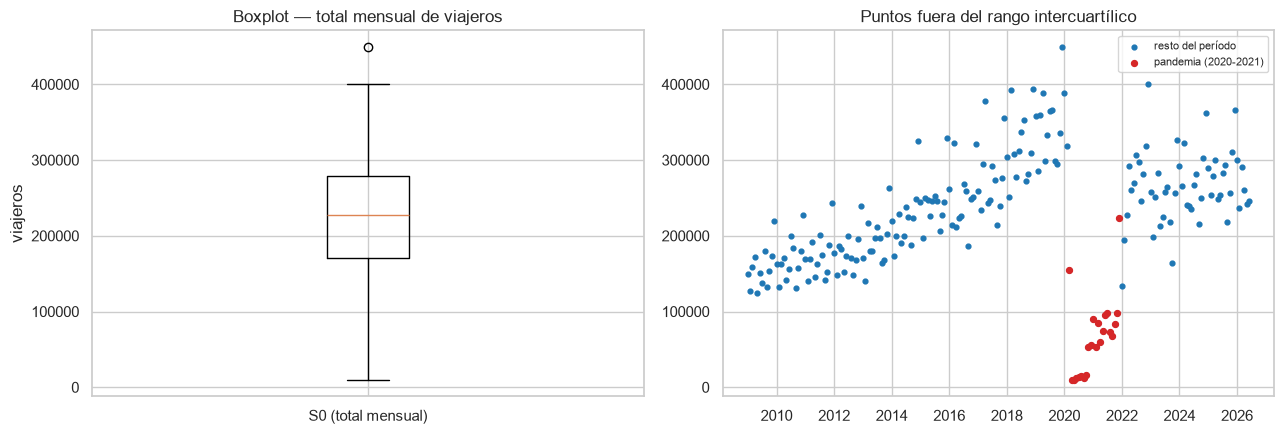

Q1=170,714  Q3=278,341  IQR=107,627
límites IQR: [9,274, 439,781]

1 meses atípicos por la regla IQR:
fecha
2019-12-01    449114.0705
Freq: MS, Name: S0_total, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].boxplot(s0.values, vert=True, tick_labels=["S0 (total mensual)"])
axes[0].set_title("Boxplot — total mensual de viajeros")
axes[0].set_ylabel("viajeros")

meses_pandemia = s0.index[(s0.index >= "2020-03-01") & (s0.index <= "2021-12-01")]
axes[1].scatter(s0.index, s0.values, s=12, color="#1f77b4", label="resto del período")
axes[1].scatter(meses_pandemia, s0.loc[meses_pandemia], s=18, color="#d62728",
                label="pandemia (2020-2021)")
axes[1].set_title("Puntos fuera del rango intercuartílico")
axes[1].legend(fontsize=8)

q1, q3 = s0.quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
atipicos = s0[(s0 < lim_inf) | (s0 > lim_sup)]

plt.tight_layout()
fig.savefig(DIR_IMG / "1e_atipicos.png", bbox_inches="tight")
plt.show()

print(f"Q1={q1:,.0f}  Q3={q3:,.0f}  IQR={iqr:,.0f}")
print(f"límites IQR: [{lim_inf:,.0f}, {lim_sup:,.0f}]")
print(f"\n{len(atipicos)} meses atípicos por la regla IQR:")
print(atipicos)

La regla del IQR identificó como valores atípicos los meses comprendidos entre abril y agosto de 2020. Sin embargo, estos valores no corresponden a errores en los datos, sino a la fuerte caída en el ingreso de viajeros ocasionada por el cierre de fronteras durante la pandemia. Por esta razón, no se eliminaron ni se modificaron, ya que representan un evento real que tuvo un impacto importante en el comportamiento de la serie y debe tomarse en cuenta durante el análisis y el modelado.

## 1.f `describe()` y quiebre 2022→2023

In [9]:
print(s0.describe())

count       210.000000
mean     222437.680412
std       84724.938827
min        9779.000000
25%      170714.476564
50%      227605.662595
75%      278341.208767
max      449114.070500
Name: S0_total, dtype: float64


Se puede ver que la media de la serie es de 222,438 viajeros y la mediana es de 227,606, por lo que ambas medidas son bastante similares. Esto indica que la distribución de los datos no presenta una asimetría muy marcada, aunque los valores extremadamente bajos registrados durante la pandemia influyen en la distribución. Además, la desviación estándar es de 84,725 viajeros, lo que muestra una variabilidad importante en la serie. Esta variación se explica principalmente por el patrón estacional y por el impacto que tuvo la pandemia sobre el ingreso de viajeros.

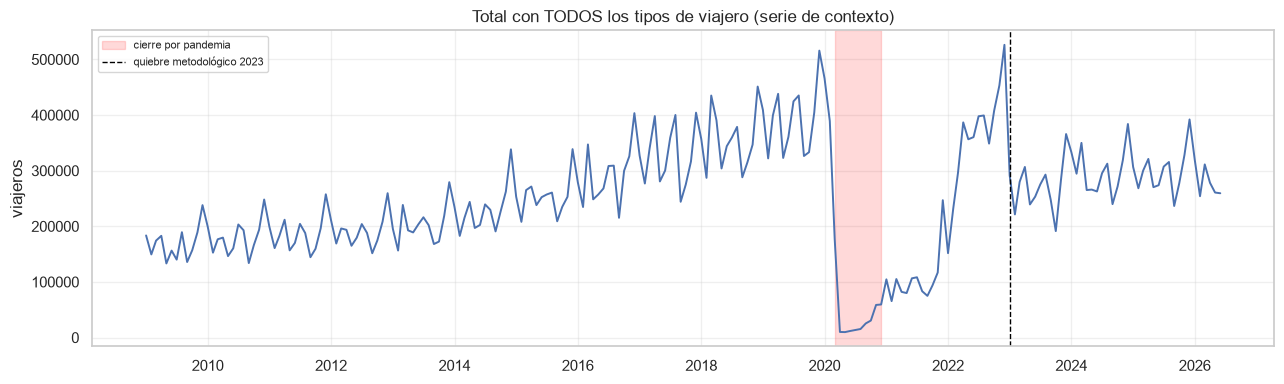

Total con todos los tipos, por año (2021-2023):
fecha
2021-01-01    1.267768e+06
2022-01-01    4.316164e+06
2023-01-01    3.248709e+06
Freq: YS-JAN, Name: S0_total_todos_tipos, dtype: float64

Total S0 (Turista+Excursionista), por año (2021-2023):
fecha
2021-01-01    1.098964e+06
2022-01-01    3.229329e+06
2023-01-01    2.917827e+06
Freq: YS-JAN, Name: S0_total, dtype: float64


In [10]:
s0_todos = cargar_serie(config.SERIE_CONTEXTO)

ax = graficar_serie(s0_todos, titulo="Total con TODOS los tipos de viajero (serie de contexto)",
                     marcar_pandemia=True)
ax.axvline(pd.Timestamp("2023-01-01"), color="black", linestyle="--", linewidth=1,
           label="quiebre metodológico 2023")
ax.legend(loc="upper left", fontsize=8)
ax.figure.savefig(DIR_IMG / "1f_quiebre_2023.png", bbox_inches="tight")
plt.show()

print("Total con todos los tipos, por año (2021-2023):")
print(s0_todos.resample("YS").sum().loc["2021":"2023"])
print()
print("Total S0 (Turista+Excursionista), por año (2021-2023):")
print(s0.resample("YS").sum().loc["2021":"2023"])

Se puede ver que en 2023 la serie que incluye todos los tipos de viajero presenta una caída muy marcada. Sin embargo, este cambio no refleja una disminución real en el turismo, sino que se debe a una modificación en la forma en que se clasifican los viajeros. En cambio, la serie utilizada para el análisis, que solo considera Turista y Excursionista, mantiene un comportamiento más consistente a lo largo de todo el período.

Por esta razón, todas las series analizadas en el proyecto se construyen únicamente con las categorías de Turista y Excursionista, ya que son las que mantienen el mismo criterio durante los 210 meses analizados. La serie que incluye todos los tipos de viajero solo se utiliza como referencia para mostrar este cambio y no forma parte del modelado.


## Comportamiento durante y después de la pandemia

In [11]:
y2019 = s0[s0.index.year == 2019].sum()
y2020 = s0[s0.index.year == 2020].sum()
nivel_2019_mensual = s0[s0.index.year == 2019].mean()
recupera = s0[(s0.index >= "2020-04-01") & (s0 >= nivel_2019_mensual)].index.min()

print(f"Total 2019: {y2019:,.0f}")
print(f"Total 2020: {y2020:,.0f}")
print(f"Caída 2020 vs 2019: {(1 - y2020 / y2019) * 100:.1f}%")
print(f"Mínimo mensual: {s0.idxmin():%Y-%m} con {s0.min():,.0f} viajeros")
print(f"Nivel promedio mensual 2019: {nivel_2019_mensual:,.0f}")
print(f"Primer mes que vuelve a igualar ese nivel: {recupera:%Y-%m} "
      f"({(recupera.year - 2020) * 12 + recupera.month - 3} meses después del colapso de marzo 2020)")

Total 2019: 4,132,251
Total 2020: 1,059,770
Caída 2020 vs 2019: 74.4%
Mínimo mensual: 2020-05 con 9,779 viajeros
Nivel promedio mensual 2019: 344,354
Primer mes que vuelve a igualar ese nivel: 2022-12 (33 meses después del colapso de marzo 2020)


Se puede ver que en 2020 el total anual de viajeros disminuyó un 74.4% con respecto a 2019, al pasar de 4.13 millones a 1.06 millones de viajeros. La mayor caída se registró en mayo de 2020, cuando solo ingresaron 9,779 viajeros, lo que refleja el fuerte impacto que tuvo el cierre de fronteras durante la pandemia.

A partir de ese momento la recuperación fue gradual y no fue hasta diciembre de 2022 cuando la serie volvió a alcanzar un nivel similar al observado antes de la pandemia. Además, la partición de los datos utilizada para entrenar y evaluar los modelos se realiza en marzo de 2021, por lo que el conjunto de entrenamiento solo incluye el período de la caída y el inicio de la recuperación. Como consecuencia, es de esperarse que los modelos tengan dificultades para representar el comportamiento de la serie durante el período de recuperación incluido en el conjunto de prueba.